# Introduction
This network represents the Twitter interaction network for the 117th United States Congress, both House of Representatives and Senate. The base data was collected via the Twitter’s API, then the empirical transmission probabilities were quantified according to the fraction of times one member retweeted, quote tweeted, replied to, or mentioned another member’s tweet. 

The dataset was compiled as part of the following publication from 2023:
```
C.G. Fink, N. Omodt, S. Zinnecker, and G. Sprint: A Congressional Twitter network dataset quantifying pairwise probability of influence. Data in Brief, 2023.
```

Other python files included in the current directory served as a part of 
```
C.G. Fink, K. Fullin, G. Gutierrez, N. Omodt, S. Zinnecker, G. Sprint, and S. McCulloch: A centrality measure for quantifying spread on weighted, directed networks. Physica A, 2023.
```

# Basic analysis

The graph is ***directed*** by default, but for the preliminary analysis, we will treat it as ***undirected***.

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
from itertools import islice


G = nx.read_edgelist("congress.edgelist", nodetype=int)


In [3]:
list(G.nodes)[:10], list(G.edges)[:10], G.adj[0]

([0, 4, 12, 18, 25, 30, 46, 55, 58, 59],
 [(0, 4),
  (0, 12),
  (0, 18),
  (0, 25),
  (0, 30),
  (0, 46),
  (0, 55),
  (0, 58),
  (0, 59),
  (0, 74)],
 AtlasView({4: {'weight': 0.0036496350364963502}, 12: {'weight': 0.002105263157894737}, 18: {'weight': 0.002347417840375587}, 25: {'weight': 0.004210526315789474}, 30: {'weight': 0.002105263157894737}, 46: {'weight': 0.010238907849829351}, 55: {'weight': 0.002105263157894737}, 58: {'weight': 0.001303780964797914}, 59: {'weight': 0.0025906735751295338}, 74: {'weight': 0.0014124293785310734}, 76: {'weight': 0.009569377990430622}, 77: {'weight': 0.002079002079002079}, 85: {'weight': 0.0017241379310344827}, 86: {'weight': 0.004454342984409799}, 87: {'weight': 0.0038535645472061657}, 154: {'weight': 0.002105263157894737}, 168: {'weight': 0.00631578947368421}, 341: {'weight': 0.01680672268907563}, 374: {'weight': 0.008620689655172414}, 401: {'weight': 0.002105263157894737}, 11: {'weight': 0.004073319755600814}, 9: {'weight': 0.0036101083032490

In [82]:
# Compute centrality measures and diameter
# Nodes with high centrality are often central players in the network and might play key roles in their communities.
degree_centrality = sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True)
closeness_centrality = sorted(nx.closeness_centrality(G).items(), key=lambda x: x[1], reverse=True)
betweenness_centrality = sorted(nx.betweenness_centrality(G).items(), key=lambda x: x[1], reverse=True)
eigenvector_centrality = sorted(nx.eigenvector_centrality(G).items(), key=lambda x: x[1], reverse=True)
clustering_coefficient = sorted(nx.clustering(G).items(), key=lambda x: x[1], reverse=True)
diameter = nx.diameter(G)

print("Graph loaded with", len(G.nodes), "nodes and", len(G.edges), "edges.")
print("Degree centrality:     ", degree_centrality)
print("Closeness centrality:  ", closeness_centrality)
print("Betweenness centrality:", betweenness_centrality)
print("Eigenvector centrality:", eigenvector_centrality)
print("Clustering coefficient:", clustering_coefficient)
print("Diameter of the graph (undirected version): ", diameter)

Graph loaded with 475 nodes and 10222 edges.
Degree centrality:      [(367, 0.45147679324894513), (322, 0.38185654008438813), (254, 0.2995780590717299), (208, 0.28270042194092826), (393, 0.27215189873417717), (190, 0.2679324894514768), (111, 0.2531645569620253), (192, 0.23839662447257381), (269, 0.2362869198312236), (385, 0.2341772151898734), (461, 0.22573839662447256), (92, 0.22151898734177214), (71, 0.21940928270042193), (147, 0.21940928270042193), (303, 0.2172995780590717), (399, 0.2151898734177215), (335, 0.20675105485232065), (188, 0.20464135021097044), (113, 0.20464135021097044), (17, 0.20042194092827004), (350, 0.1962025316455696), (389, 0.1940928270042194), (428, 0.1940928270042194), (401, 0.19198312236286919), (179, 0.19198312236286919), (315, 0.19198312236286919), (105, 0.18987341772151897), (137, 0.18565400843881855), (436, 0.18143459915611812), (215, 0.1772151898734177), (452, 0.1772151898734177), (87, 0.1729957805907173), (298, 0.1729957805907173), (134, 0.1729957805907173

In [6]:
nx.diameter(nx.read_edgelist("congress.edgelist", nodetype=int, create_using=nx.DiGraph()))

NetworkXError: Found infinite path length because the digraph is not strongly connected

Error message above left here to call attention to the graph ***not*** being ***strongly connected***

# Searching communities and analysing robustness

In [32]:
# Community detection using the Girvan-Newman algorithm
communities = girvan_newman(G)
top_level_communities = next(islice(communities, 100))  # Get the 100th division of communities
community_list = [list(community) for community in top_level_communities]
print("\nCommunities detected:  ", community_list)
print("Number of communities: ", len(community_list))


Communities detected:   [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216

The Girvan-Newman algorithm detecting only 2 communities despite 100 edges being removed suggests that the network is very well-connected and constitues a singular giant component without any explicit bridges within. Also, the second "community" of the two is a single node, further underscoring the interconnectivity of the graph as a whole.

In [33]:
len(G.nodes()), len(G.edges)

(475, 10222)

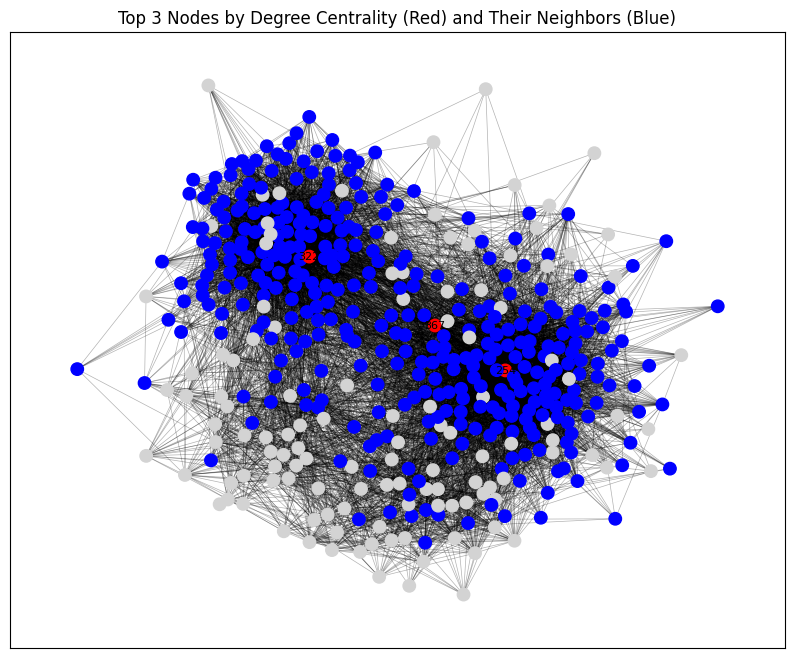

In [34]:
# 1. Get top n nodes by degree centrality
n = 3
top_n = [node[0] for node in degree_centrality[:n]]

# 2. Collect all neighbors of those top n nodes
neighbors = set()
for node in top_n:
    neighbors.update(G.neighbors(node))

# Remove overlap — a top node shouldn't be recolored as a neighbor
neighbors -= set(top_n)

# 3. Define node colors
node_colors = []
for node in G.nodes:
    if node in top_n:
        node_colors.append("red")
    elif node in neighbors:
        node_colors.append("blue")
    else:
        node_colors.append("lightgray")


# 4. Draw graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=80)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)

# Optionally label the top nodes
nx.draw_networkx_labels(G, pos, labels={n: n for n in top_n}, font_color="black", font_size=8)

plt.title(f"Top {n} Nodes by Degree Centrality (Red) and Their Neighbors (Blue)")
plt.show()

While the graph is overly dense and as such hard to make sense of, it still illustrates well how connected the entire graph is, with only the top 3 most central nodes connecting to hundreds of other nodes. This reflects well the observation in real life that networks of human relationships are usually very rich in edges. 

Number of neighbours for the top 3 nodes: 348


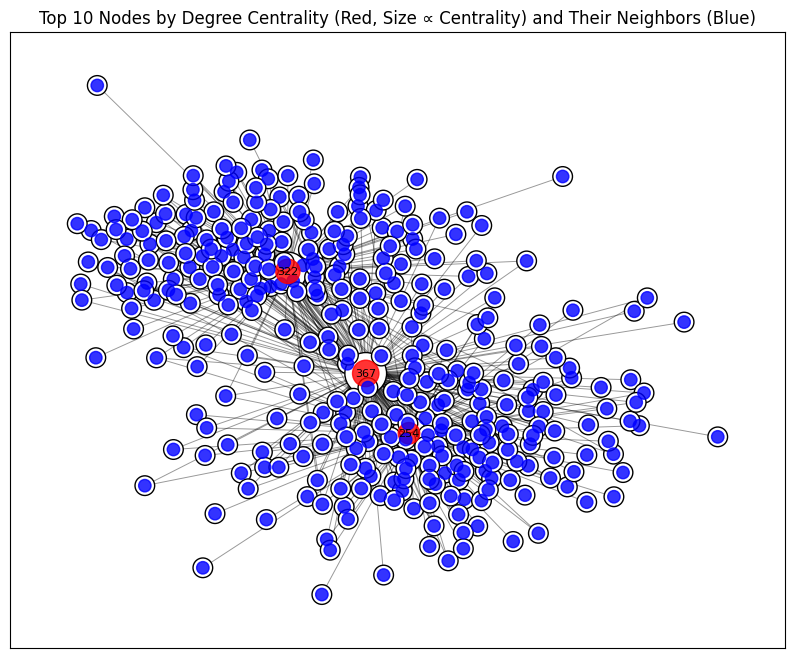

In [87]:
# 1. Get top 10 nodes by degree centrality
degree_centrality = nx.degree_centrality(G)
n=3
top_n = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:n]

# 2. Collect neighbors of the top 10
neighbors = set()
for node in top_n:
    neighbors.update(G.neighbors(node))
neighbors -= set(top_n)
print(f"Number of neighbours for the top {n} nodes: {len(neighbors)}")

# 3. Create subgraph induced by top nodes + their neighbors
sub_nodes = set(top_n) | neighbors
H = G.subgraph(sub_nodes).copy()

# 3b. Filter edges to only those connected to top10 nodes
edges_to_draw = [(u, v) for u, v in H.edges() if u in top_n or v in top_n]

# 4. Compute node sizes and colors
node_colors = []
node_sizes = []
for n in H.nodes():
    if n in top_n:
        node_colors.append("red")
        # Scale size relative to centrality
        # Multiply by a constant to make sizes visible (adjust as needed)
        node_sizes.append(2000 * degree_centrality[n])
    else:
        node_colors.append("blue")
        node_sizes.append(200)  # constant size for neighbors

# 5. Draw
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42)

nx.draw_networkx_nodes(H, pos, node_color="white",     node_size=node_sizes, edgecolors="black")
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=[size*0.4 for size in node_sizes], alpha=0.8)

nx.draw_networkx_edges(H, pos, edgelist=edges_to_draw, alpha=0.4, width=0.7)
nx.draw_networkx_labels(H, pos, labels={n: n for n in top_n}, font_color="black", font_size=8)

plt.title("Top 10 Nodes by Degree Centrality (Red, Size ∝ Centrality) and Their Neighbors (Blue)")
plt.show()

By exclusively visualizing the edges between the top N nodes and their neighbours, the graph becomes a bit easier to showcase, but the most important takeaway is the fact that even just by using the top 3 nodes, they still have 348 neighbours, which is over 73% of the total 475 nodes.

# Using The Louvain method for community detection

Since the Girvan-Newman method didn't prove particularly informative, let's see if the Louvain method provides us more insight.

Network modularity: 0.444
Community assortativity: 0.621


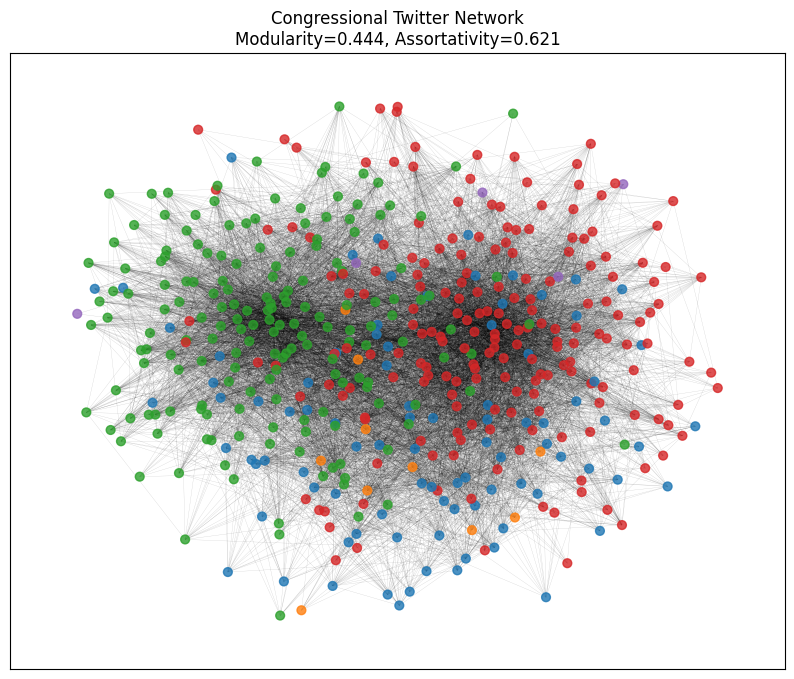

In [88]:
import community as community_louvain
H = G.copy()
# --- 1. Compute communities ---
partition = community_louvain.best_partition(H.to_undirected(), weight='weight')

# Add community attribute to nodes
nx.set_node_attributes(H, partition, "community")

# --- 2. Compute modularity (measure of polarization) ---
modularity = community_louvain.modularity(partition, H.to_undirected(), weight='weight')
print(f"Network modularity: {modularity:.3f}")

# --- 3. Compute assortativity (homophily) based on communities ---
assortativity = nx.attribute_assortativity_coefficient(H, "community")
print(f"Community assortativity: {assortativity:.3f}")

# --- 4. Visualization ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, k=0.15, seed=42, weight='weight')

# Get colors by community
communities = set(partition.values())
colors = plt.cm.tab10(range(len(communities)))
node_colors = [colors[partition[n] % len(colors)] for n in H.nodes()]

nx.draw_networkx_nodes(H, pos, node_size=40, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(H, pos, width=0.2, alpha=0.2, arrows=False)

plt.title(f"Congressional Twitter Network\nModularity={modularity:.3f}, Assortativity={assortativity:.3f}")
plt.show()

While a modularity of ~0.4 suggest that the communities are not particularly well-separated, the relatively high assortativity of ~0.6 shows that nodes are still much more likely to communicate within the community than outside.

Modularity: 0.441
Assortativity: 0.610
Bridging edges: 2589
Bridging nodes: 472
Total nodes: 475


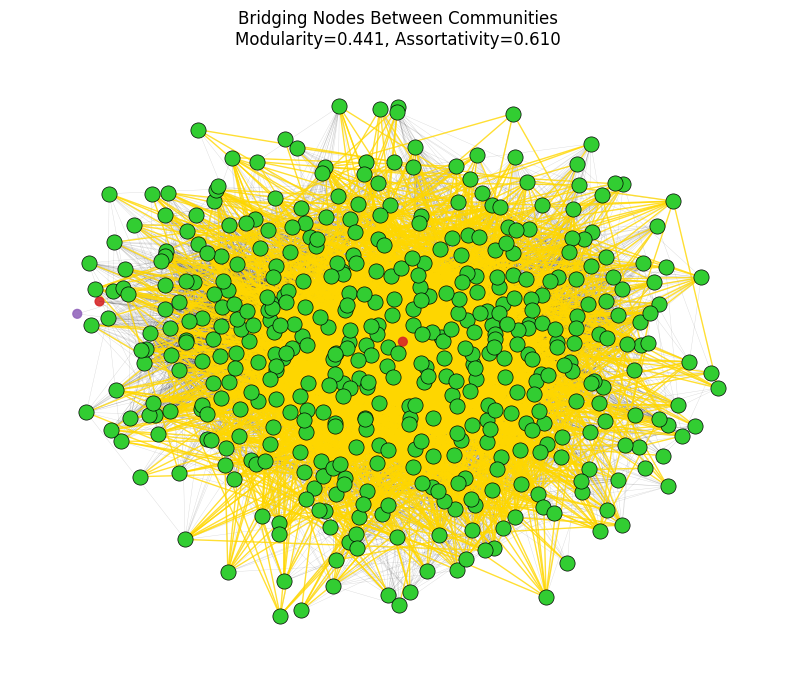

In [89]:
import community as community_louvain

# --- Assume you already have a directed weighted graph G ---
H = G.copy()

# --- 1. Compute communities (Louvain) ---
partition = community_louvain.best_partition(H.to_undirected(), weight='weight')
nx.set_node_attributes(H, partition, "community")

# --- 2. Compute metrics ---
modularity = community_louvain.modularity(partition, H.to_undirected(), weight='weight')
assortativity = nx.attribute_assortativity_coefficient(H, "community")
print(f"Modularity: {modularity:.3f}")
print(f"Assortativity: {assortativity:.3f}")

# --- 3. Identify bridging edges (edges connecting different communities) ---
bridging_edges = [(u, v) for u, v in H.edges() if partition[u] != partition[v]]
bridging_nodes = set([u for u, v in bridging_edges] + [v for u, v in bridging_edges])

print(f"Bridging edges: {len(bridging_edges)}")
print(f"Bridging nodes: {len(bridging_nodes)}")
print(f"Total nodes: {len(H.nodes())}")
# --- 4. Visualization ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, k=0.15, seed=42, weight='weight')

# Node colors by community
communities = set(partition.values())
colors = plt.cm.tab10(range(len(communities)))
node_colors = [colors[partition[n] % len(colors)] for n in H.nodes()]

# Draw normal edges and bridging edges separately
nx.draw_networkx_edges(H, pos, edgelist=[e for e in H.edges() if e not in bridging_edges],
                       alpha=0.15, width=0.3, arrows=False)
nx.draw_networkx_edges(H, pos, edgelist=bridging_edges,
                       edge_color="gold", width=1.0, alpha=0.8, arrows=False)

# Draw normal and bridging nodes
nx.draw_networkx_nodes(H, pos,
                       nodelist=[n for n in H.nodes() if n not in bridging_nodes],
                       node_color=[node_colors[list(H.nodes()).index(n)] for n in H.nodes() if n not in bridging_nodes],
                       node_size=40, alpha=0.9)
nx.draw_networkx_nodes(H, pos,
                       nodelist=list(bridging_nodes),
                       node_color="limegreen", node_size=120, edgecolors="black", linewidths=0.5)

plt.title(f"Bridging Nodes Between Communities\nModularity={modularity:.3f}, Assortativity={assortativity:.3f}")
plt.axis("off")
plt.show()

Underscoring the low modularity, it is apparent that almost every node performs inter-community communication.

In [ ]:
import pandas as pd
intra_weights = []
inter_weights = []

for u, v, d in H.edges(data=True):
    w = d.get('weight', 1)
    if partition[u] == partition[v]:
        intra_weights.append(w)
    else:
        inter_weights.append(w)

df = pd.DataFrame({
    "Type": ["Intra"] * len(intra_weights) + ["Inter"] * len(inter_weights),
    "Weight": intra_weights + inter_weights
})

df.groupby("Type")["Weight"].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Inter,2709.0,0.004754,0.004575,0.000526,0.002096,0.003356,0.005618,0.053333
Intra,7513.0,0.006212,0.007434,0.000526,0.002688,0.004049,0.006993,0.130564


Dataframe description in line with homophily, having a 30% larger mean for intra-community weights, with a maximum value that is 260% larger than that of the inter-community weights.

Seed nodes: [367, 322, 393, 71, 399, 436, 179, 254, 105, 87]
Average cascade size over 50 runs (including 10 seeds)
15.7


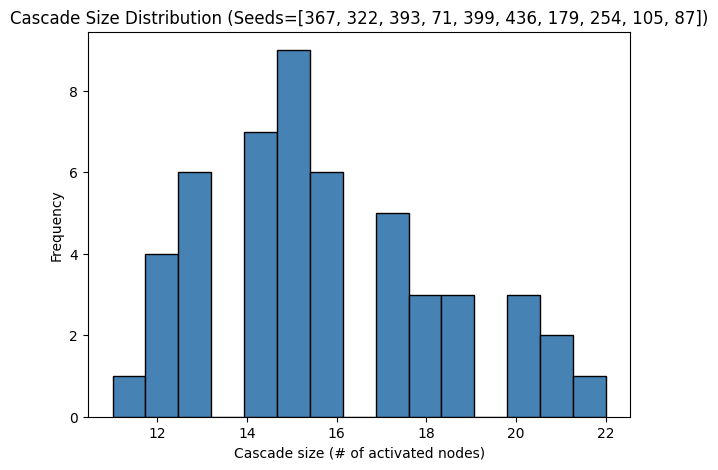

/home/martin/projects/uni/Social_networks/venv/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


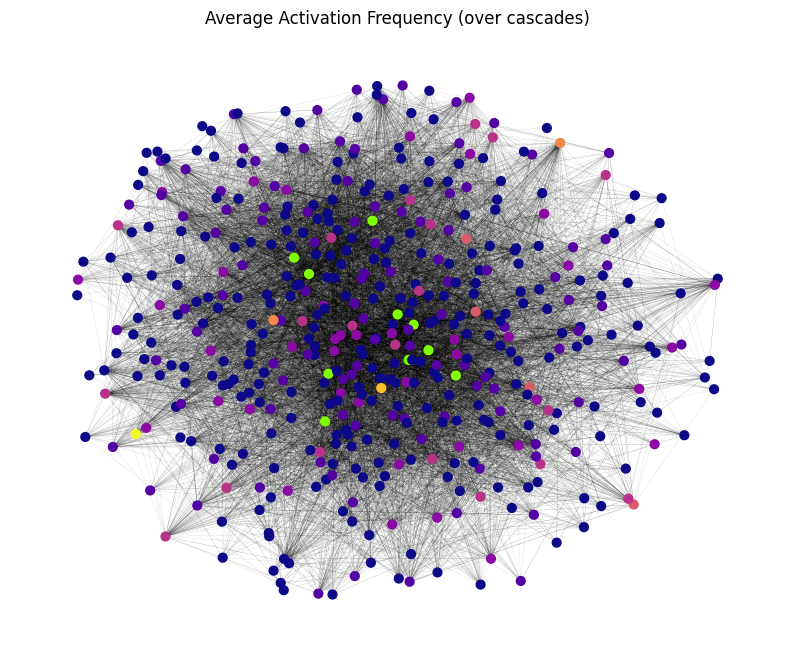

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt
from collections import defaultdict
G = nx.read_edgelist(
    'congress.edgelist',
    create_using=nx.DiGraph(),
    nodetype=int,
    data=True,
    comments=None
)

# --- PARAMETERS ---
num_simulations = 50       # how many runs to average over
max_steps = 5             # max cascade depth
seed_selection = "top"     # "top" or "random"
num_seeds = 10              # how many seed nodes to start cascades with

# --- PREPARE GRAPH ---
# Ensure we have weights as probabilities between 0 and 1
for u, v, d in G.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 0.1  # default fallback
    else:
        d['weight'] = min(max(float(d['weight']), 0.0), 1.0)

# --- SELECT SEED NODES ---
if seed_selection == "top":
    # by out-degree centrality (proxy for influence)
    centrality = nx.out_degree_centrality(G)
    seed_nodes = sorted(centrality, key=centrality.get, reverse=True)[:num_seeds]
else:
    seed_nodes = random.sample(list(G.nodes()), num_seeds)

print(f"Seed nodes: {seed_nodes}")

# --- INDEPENDENT CASCADE SIMULATION ---
def independent_cascade(G, seeds, max_steps=10):
    active = set(seeds)
    newly_active = set(seeds)
    steps = [set(seeds)]

    for _ in range(max_steps):
        next_newly_active = set()
        for u in newly_active:
            for v in G.successors(u):
                if v not in active:
                    p = G[u][v]['weight']
                    # print(f"Trying to activate {v} from {u} with probability {p}")
                    if random.random() < p:
                        next_newly_active.add(v)
        if not next_newly_active:
            break
        active |= next_newly_active
        steps.append(next_newly_active)
        newly_active = next_newly_active
    return steps, active

# --- RUN MULTIPLE SIMULATIONS ---
cascade_sizes = []
activation_counts = defaultdict(int)

for _ in range(num_simulations):
    steps, active_nodes = independent_cascade(G, seed_nodes, max_steps=max_steps)
    # print(f"Cascade steps: {steps}")
    cascade_sizes.append(len(active_nodes))
    for n in active_nodes:
        activation_counts[n] += 1

avg_cascade_size = sum(cascade_sizes) / num_simulations
print(f"Average cascade size over {num_simulations} runs (including {num_seeds} seeds)\n{avg_cascade_size:.1f}")

# --- PLOT 1: Distribution of cascade sizes ---
plt.figure(figsize=(7,5))
plt.hist(cascade_sizes, bins=15, color='steelblue', edgecolor='black')
plt.title(f"Cascade Size Distribution (Seeds={seed_nodes})")
plt.xlabel("Cascade size (# of activated nodes)")
plt.ylabel("Frequency")
plt.show()

# --- PLOT 2: Activation heatmap (excluding seeds from normalization) ---
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42, k=0.15, weight='weight')

# Exclude seed nodes from normalization
non_seed_acts = {n: activation_counts[n] for n in G.nodes() if n not in seed_nodes}
max_act = max(non_seed_acts.values()) if non_seed_acts else 1.0

# Assign colors: chartreuse for seeds, heatmap for others
node_colors = []
for n in G.nodes():
    if n in seed_nodes:
        node_colors.append('chartreuse')
    else:
        val = activation_counts[n] / max_act if n in non_seed_acts else 0
        node_colors.append(plt.cm.plasma(val))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap='plasma', node_size=40)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.2, arrows=False)
plt.title("Average Activation Frequency (over cascades)")
plt.axis("off")
plt.show()

Independent Cascade (IC) showing how information spreads from the top N seeds with the highest centrality. It should be noted how relatively few spreads occured in the given number of steps, owing to the fact that despite the highly connected nature of the graph, most of the edges have extremely low weights.

In [ ]:
activation_counts

defaultdict(int,
            {322: 50,
             71: 50,
             72: 4,
             393: 50,
             140: 5,
             399: 50,
             207: 4,
             276: 4,
             278: 1,
             87: 50,
             355: 3,
             105: 50,
             297: 2,
             109: 2,
             367: 50,
             112: 2,
             242: 2,
             179: 50,
             436: 50,
             114: 4,
             374: 6,
             254: 50,
             331: 2,
             255: 5,
             448: 1,
             191: 1,
             200: 1,
             328: 1,
             269: 4,
             469: 3,
             111: 6,
             127: 2,
             134: 1,
             423: 2,
             299: 2,
             139: 2,
             365: 3,
             401: 5,
             408: 2,
             311: 3,
             160: 1,
             416: 3,
             232: 1,
             80: 1,
             406: 1,
             279: 6,
           